In [1]:
import pandas as pd
import numpy as np
import sklearn 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
path=r"E:\Downloads\preprocessd_data_cleaned - preprocessd_data_cleaned.csv"

In [3]:
df=pd.read_csv(path)
df

,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,weekly_max_night_mins,videos_watched,customer_support_calls,churn
0,0,-0.264643,-0.946659,0,0,-1.508785,0.722258,-0.944404,-1.403000,-0.415473,0
1,0,0.029654,1.235009,0,0,0.304821,-0.901748,-0.688523,-0.599124,0.347522,0
2,0,2.580235,0.658246,0,0,-2.266627,0.613991,-0.483818,-1.403000,2.636507,1
3,0,-1.441834,0.783629,0,1,0.638123,-0.252146,0.079121,-0.197185,1.110517,0
4,0,0.127754,2.288228,0,0,-0.333851,0.253101,-0.893228,1.008630,-0.415473,0
...,...,...,...,...,...,...,...,...,...,...,...
3401,1,-0.805656,0.479710,0,0,0.887802,0.552184,0.865765,-0.495634,-0.415473,1
3402,0,0.477826,0.674425,0,0,2.038061,-0.931071,0.567257,2.100185,0.235227,1
3403,0,-0.550521,0.426099,0,1,-0.410669,0.344847,-0.729485,-0.403904,1.873512,1
3404,0,0.004651,-0.444637,0,0,1.359751,-0.847121,-0.715010,-0.197185,-1.178468,1


In [4]:
X=df.drop('churn',axis=1)
y=df['churn']

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1234)

In [7]:
X_train.shape

(2724, 10)

In [8]:
y_train.shape

(2724,)

In [9]:
X_test.shape

(682, 10)

In [10]:
y_test.shape

(682,)

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,f1_score,auc,precision_recall_curve,precision_score,recall_score,r2_score,mean_absolute_error,mean_squared_error

- no hyperparameter tuning

In [13]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

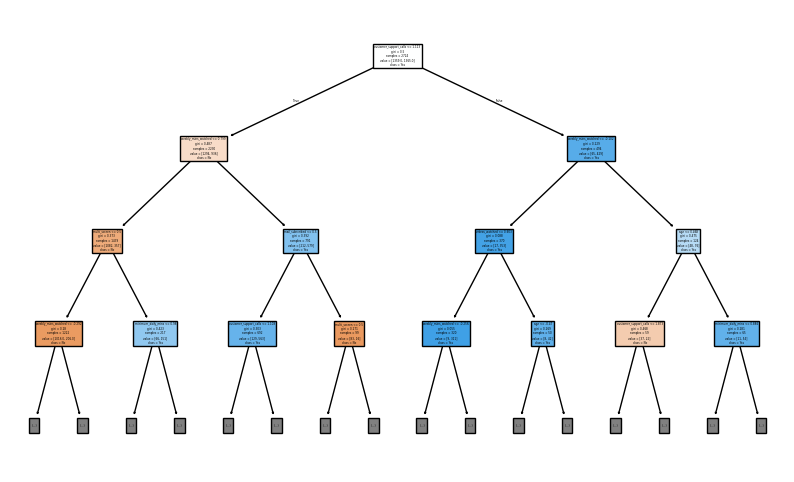

In [14]:
plt.figure(figsize=(10,6))
plot_tree(dt,feature_names=X.columns,max_depth=3,class_names=['No','Yes'],filled=True)
plt.show()

## Predictions

In [16]:
y_pred=dt.predict(X_test)
y_pred

array([0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,

In [17]:
new_df=pd.DataFrame()

In [18]:
new_df=X_test.copy()
new_df['y_test']=y_test
new_df['y_pred']=y_pred

In [19]:
new_df

,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,weekly_max_night_mins,videos_watched,customer_support_calls,y_test,y_pred
697,0,1.403044,-1.147273,1,0,0.636261,-0.035611,-1.302638,-0.599124,-0.415473,0,0
268,0,-1.932331,0.532863,0,1,0.343924,-1.587439,-1.200286,-0.599124,1.110517,1,0
2055,0,-0.257476,-0.473889,0,0,1.041150,-0.408828,-0.083147,0.273394,0.347522,1,1
114,0,-0.068445,-1.122196,0,1,-0.920387,0.289190,0.693237,0.204753,1.873512,1,1
1137,0,-1.049437,-0.695893,0,1,-1.551611,-1.443083,0.846766,-0.197185,1.873512,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,0,-1.324794,0.168565,0,0,-2.898447,-1.161027,-0.781879,-1.240835,1.873512,1,1
1642,0,-0.853239,1.535929,0,0,-0.527501,-2.237041,-1.660872,0.204753,-0.415473,0,0
1635,0,0.225853,1.209932,0,0,-0.030342,0.433546,-0.125584,-0.197185,-0.415473,0,0
739,0,-0.853239,1.009319,0,0,-1.249964,2.201907,-0.790875,0.606692,-1.178468,0,0


In [20]:
tp=np.sum((y_test==1) & (y_pred==1))   # TP

In [21]:
tn=np.sum((y_test==0) & (y_pred==0))   # TN

In [22]:
fp=np.sum((y_test==0) & (y_pred==1))   # FP

In [23]:
fn=np.sum((y_test==1) & (y_pred==0))   # FN

In [24]:
tp,tn,fp,fn

(304, 297, 47, 34)

In [25]:
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score
ps=precision_score(y_test,y_pred)
rs=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
confusion_matrix=confusion_matrix(y_test,y_pred)

In [26]:
print(f"precision_score : {ps}, Recall Score : {rs}, F1 Score : {f1}, Accuracy : {accuracy},confusion_matrix : {confusion_matrix}")

precision_score : 0.8660968660968661, Recall Score : 0.8994082840236687, F1 Score : 0.8824383164005806, Accuracy : 0.8812316715542522,confusion_matrix : [[297  47]
 [ 34 304]]


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[297  47]
 [ 34 304]]


In [28]:
cm.flatten()

array([297,  47,  34, 304], dtype=int64)

In [99]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

acc = round(accuracy_score(y_test, y_pred), 2)
pr  = round(precision_score(y_test, y_pred), 2)
rc  = round(recall_score(y_test, y_pred), 2)
f1  = round(f1_score(y_test, y_pred), 2)

pd.DataFrame(
    [f'{acc*100}%', f'{pr*100}%', f'{rc*100}%', f'{f1*100}%', tp, fp, tn, fn],
    columns=['Decision tree'],
    index=['Accuracy', 'precision', 'Recall', 'F1', 'TP', 'FP', 'TN', 'FN']
)

,Decision tree
Accuracy,88.0%
precision,86.0%
Recall,91.0%
F1,88.0%
TP,304
FP,47
TN,297
FN,34


In [64]:
y_predict_proba=dt.predict_proba(X_test)

In [ ]:
df=pd.DataFrame(y_predict_proba,columns=['P(No)','P(Yes)'])

In [95]:
df['P(Yes)']

0      0.0
1      0.0
2      1.0
3      1.0
4      1.0
      ... 
677    1.0
678    0.0
679    0.0
680    0.0
681    0.0
Name: P(Yes), Length: 682, dtype: float64

In [89]:
p_yes=(y_predict_proba[:,1])

In [101]:
auc=roc_auc_score(y_test,p_yes)

In [97]:
roc_auc_score(y_test,df['P(Yes)'])

0.871215769918811

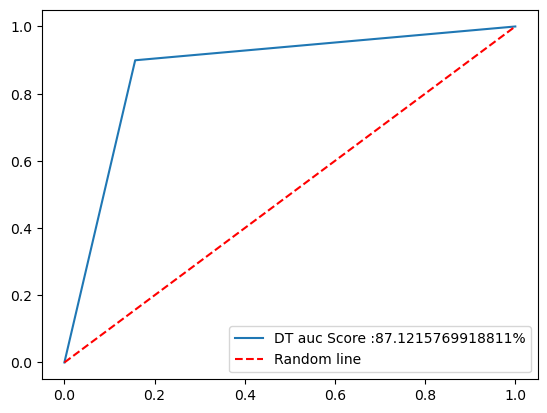

In [107]:
from sklearn.metrics import roc_curve
fpr,tpr,thresholds=roc_curve(y_test,p_yes)
plt.plot(fpr,tpr,label=f'DT auc Score :{auc*100}%')
plt.plot([0,1],[0,1],color='red',linestyle='dashed',label='Random line')
plt.legend()
plt.show()